# AI-Driven Growth: Insights into Revenue Trends and Stock Reactions

**Prepared by:** Siti Amira Hanis Binti Nor Ramlee  
**Period:** 2015–2024  
**Companies:** Google, Meta, OpenAI

## 1. Context

### Objective
Understand how AI-related events and R&D spending influence company performance — both revenue growth and stock behavior — across Google, Meta, and OpenAI from 2015 to 2024.

### Purpose
| # | Purpose |
|---|---------|
| 1 | Identify which AI investments and events drive measurable financial impact |
| 2 | Help management and investors make informed strategic decisions |
| 3 | Highlight patterns for forecasting growth and market reactions |

### Key Metrics
| Metric | Description |
|--------|-------------|
| AI Revenue Growth (%) | Year-over-year change in AI-driven revenue |
| R&D Spending (USD Mn) | Annual research & development investment |
| Stock Impact (%) | Daily stock price movement attributed to AI activity |
| Stock Volatility | Standard deviation of stock impact — measures consistency |

### Research Questions
| # | Question |
|---|---------|
| RQ1 | How does AI revenue growth relate to stock price volatility? |
| RQ2 | How do event types affect stock performance? |
| RQ3 | Which periods had extreme stock movements? |

### Datasets
| Dataset | Records | Key Columns |
|---------|---------|-------------|
| Daily Financial Market | 10,959 | Company, Date, R&D Spending, AI Revenue, Growth %, Stock Impact % |
| AI Market Events | 233 (cleaned) | Event Date, Company, Event Type, Stock Impact % |

## 2.Data Preparation
### 2.1 Data Cleaning & Data Transformation:

- Handle missing values in both datasets (e.g., missing prices, order dates, or last visit dates).

In [4]:
import pandas as pd #Data manipulation & analysis
import seaborn as sns #Advanced data visualization
import matplotlib.pyplot as plt #Basic plotting
import numpy as np #numerical operations
import matplotlib.colors as mcolors
plt.show()

### 2.2 Load Dataset 1 — Daily Financial Market

In [6]:
DFM = pd.read_csv("ai_financial_market_daily.csv")
DFM

DFM.info()

missing_count = DFM['Stock_Impact_%'].isnull().sum()
print(f"\nMissing Stock_Impact_% values: {missing_count}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Data_ID              10959 non-null  object 
 1   Date                 10959 non-null  object 
 2   Company              10959 non-null  object 
 3   R&D_Spending_USD_Mn  10959 non-null  float64
 4   AI_Revenue_USD_Mn    10959 non-null  float64
 5   AI_Revenue_Growth_%  10959 non-null  float64
 6   Stock_Impact_%       10955 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB

Missing Stock_Impact_% values: 4


### 2.3 Load Dataset 2 — AI Market Events

In [7]:
DFE = pd.read_csv("ai_financial_market_event.csv")
DFE

DFE.info()

missing_count = DFE['Event'].isnull().sum()
print(f"\nMissing Event values: {missing_count}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Data_ID  10959 non-null  object
 1   Event    233 non-null    object
dtypes: object(2)
memory usage: 171.4+ KB

Missing Event values: 10726


### 2.4 Data Cleaning

#### Stock Impact % — Missing Value Treatment

Stock_Impact_% has 4 missing values. Before filling, we check the distribution to choose the right imputation method. (Check statistics for Stock_Impact %)

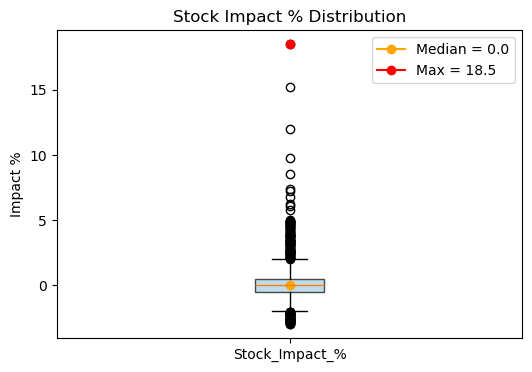

In [8]:
data = DFM['Stock_Impact_%'].dropna()
plt.figure(figsize=(6,4))

box = plt.boxplot(data, vert=True, patch_artist=True, showfliers=True)

for patch in box['boxes']:
    patch.set_facecolor('#a6cee3')
    patch.set_alpha(0.7)


median_val = data.median()
plt.plot([1], [median_val], marker='o', color='orange', label=f"Median = {median_val}")


max_val = data.max()
plt.plot([1], [max_val], marker='o', color='red', label=f"Max = {max_val}")


plt.title("Stock Impact % Distribution")
plt.ylabel("Impact %")
plt.xticks([1], ['Stock_Impact_%'])
plt.legend()

plt.show()

**Decision:** Distribution is slightly skewed with outliers (max ~18.5%). Median is more robust than mean for imputation.

**Remark:** Most stock impacts are small, but occasional extremes (e.g., 18.5%) are investigated as unusual events.


In [9]:
DFM['Stock_Impact_%'].describe() #max point got highest point, to confirm for the unusual event

count    10955.000000
mean         0.026206
std          0.748482
min         -2.980000
25%         -0.500000
50%          0.000000
75%          0.510000
max         18.500000
Name: Stock_Impact_%, dtype: float64

In [10]:
# DATA CLEANING FOR STOCK_IMPACT %
#=================================

Cleaned_DFM = DFM.copy()

# Stock Impact % statistics
stock_stats = Cleaned_DFM['Stock_Impact_%'].describe()
mean_val = stock_stats['mean']
print(f"Mean Val: {mean_val}")
median_val = stock_stats['50%']
print(f"Median Val: {median_val}")
q1 = Cleaned_DFM['Stock_Impact_%'].quantile(0.25) #-0.50
q3 = Cleaned_DFM['Stock_Impact_%'].quantile(0.75) #0.51
iqr = q3 - q1
print(f"IQR: {iqr}")

# Fill missing values with median (central value of IQR) to reflect typical stock impact without skew from outliers
Cleaned_DFM['Stock_Impact_%'] = Cleaned_DFM['Stock_Impact_%'].fillna(median_val) 

print(Cleaned_DFM.info())

Cleaned_DFM


Mean Val: 0.026206298493838428
Median Val: 0.0
IQR: 1.01
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Data_ID              10959 non-null  object 
 1   Date                 10959 non-null  object 
 2   Company              10959 non-null  object 
 3   R&D_Spending_USD_Mn  10959 non-null  float64
 4   AI_Revenue_USD_Mn    10959 non-null  float64
 5   AI_Revenue_Growth_%  10959 non-null  float64
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB
None


,Data_ID,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%
0,A1,1/1/2015,OpenAI,5.92,0.63,-36.82,-0.36
1,A2,2/1/2015,OpenAI,5.41,1.81,80.59,0.41
2,A3,3/1/2015,OpenAI,4.50,0.61,-38.88,0.23
3,A4,4/1/2015,OpenAI,5.45,0.95,-5.34,0.93
4,A5,5/1/2015,OpenAI,3.40,1.48,48.45,-0.09
...,...,...,...,...,...,...,...
10954,A10955,27/12/2024,Meta,100.19,103.54,417.68,-0.66
10955,A10956,28/12/2024,Meta,99.12,102.37,411.86,-0.57
10956,A10957,29/12/2024,Meta,98.95,103.11,415.54,-0.52
10957,A10958,30/12/2024,Meta,100.74,103.21,416.03,0.22


In [11]:
# DATA CLEANING FOR EVENT
#========================

Cleaned_DFE = DFE.copy()
Cleaned_DFE = DFE.dropna(subset=['Event'])
Cleaned_DFE.reset_index(drop=True, inplace=True)

print(Cleaned_DFE.info())

Cleaned_DFE

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Data_ID  233 non-null    object
 1   Event    233 non-null    object
dtypes: object(2)
memory usage: 3.8+ KB
None


,Data_ID,Event
0,A20,Cloud AI launch
1,A78,AI ethics policy update
2,A167,AI ethics policy update
3,A247,AI-powered search update
4,A319,AI Ads Optimization upgrade
...,...,...
228,A10818,AI Video Recommendation upgrade
229,A10835,AI-powered search update
230,A10919,AI Ads Optimization upgrade
231,A10927,AI speech recognition release


### 2.5 Data Joining

Merge both datasets on `Data_ID` to combine financial metrics with event information.

In [16]:
df = Cleaned_DFM.merge(Cleaned_DFE, on="Data_ID", how="left")

df.head()

Cleaned_DFM["Company"].unique()

Cleaned_DFM["Year"] = Cleaned_DFM["Date"].dt.year

Cleaned_DFM.head()

Cleaned_DFM.info()
Cleaned_DFM["Date"] = pd.to_datetime(Cleaned_DFM["Date"], format="%d/%m/%Y")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Data_ID              10959 non-null  object        
 1   Date                 10959 non-null  datetime64[ns]
 2   Company              10959 non-null  object        
 3   R&D_Spending_USD_Mn  10959 non-null  float64       
 4   AI_Revenue_USD_Mn    10959 non-null  float64       
 5   AI_Revenue_Growth_%  10959 non-null  float64       
 6   Stock_Impact_%       10959 non-null  float64       
 7   Year                 10959 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(1), object(2)
memory usage: 642.3+ KB


### 2.6 Data Manipulation and Data Transformation:

In [24]:
# Show the Companies Name
#=========================

Cleaned_DFM["Company"].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [25]:
# Create a new column for "Year" only
#====================================

Cleaned_DFM["Year"] = Cleaned_DFM["Date"].dt.year

Cleaned_DFM.head()
#The first dataset (Daily Financial Market) has been cleaned; all other datasets remain unchanged.

,Data_ID,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,Year
0,A1,2015-01-01,OpenAI,5.92,0.63,-36.82,-0.36,2015
1,A2,2015-01-02,OpenAI,5.41,1.81,80.59,0.41,2015
2,A3,2015-01-03,OpenAI,4.50,0.61,-38.88,0.23,2015
3,A4,2015-01-04,OpenAI,5.45,0.95,-5.34,0.93,2015
4,A5,2015-01-05,OpenAI,3.40,1.48,48.45,-0.09,2015


In [14]:
# Convert 'Date' to datetime format

Cleaned_DFM.info()
Cleaned_DFM["Date"] = pd.to_datetime(Cleaned_DFM["Date"], format="%d/%m/%Y")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Data_ID              10959 non-null  object 
 1   Date                 10959 non-null  object 
 2   Company              10959 non-null  object 
 3   R&D_Spending_USD_Mn  10959 non-null  float64
 4   AI_Revenue_USD_Mn    10959 non-null  float64
 5   AI_Revenue_Growth_%  10959 non-null  float64
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


---
## 3. Exploratory Data Analysis

### 3.1 R&D Spending vs AI Revenue Over Time

In [20]:
# 1. # Show the Companies Name
# =========================
print("Companies in dataset:")
print(Cleaned_DFM["Company"].unique())

# 2. # Convert 'Date' to datetime format
# ======================================
print("\nConverting Date to datetime...")
print("Before conversion - Date dtype:", Cleaned_DFM['Date'].dtype)
print("Sample dates:", Cleaned_DFM['Date'].head(3).tolist())

Cleaned_DFM["Date"] = pd.to_datetime(Cleaned_DFM["Date"], format="%d/%m/%Y")
print("After conversion - Date dtype:", Cleaned_DFM['Date'].dtype)

# 3. # Create a new column for "Year" only
# ========================================
print("\nCreating Year column...")
Cleaned_DFM["Year"] = Cleaned_DFM["Date"].dt.year
print("Year column created. Years found:", sorted(Cleaned_DFM['Year'].unique()))

print("\nFirst 5 rows:")
print(Cleaned_DFM[['Date', 'Year', 'Company', 'AI_Revenue_USD_Mn']].head())


print("\nDataset info:")
Cleaned_DFM.info()

Companies in dataset:
['OpenAI' 'Google' 'Meta']

Converting Date to datetime...
Before conversion - Date dtype: datetime64[ns]
Sample dates: [Timestamp('2015-01-01 00:00:00'), Timestamp('2015-01-02 00:00:00'), Timestamp('2015-01-03 00:00:00')]
After conversion - Date dtype: datetime64[ns]

Creating Year column...
Year column created. Years found: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

First 5 rows:
        Date  Year Company  AI_Revenue_USD_Mn
0 2015-01-01  2015  OpenAI               0.63
1 2015-01-02  2015  OpenAI               1.81
2 2015-01-03  2015  OpenAI               0.61
3 2015-01-04  2015  OpenAI               0.95
4 2015-01-05  2015  OpenAI               1.48

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------       

In [21]:
sum_aggregation = df.pivot_table(
    index="Year",
    columns="Company",
    values=["R&D_Spending_USD_Mn","AI_Revenue_USD_Mn"],
    aggfunc='sum'
)
print(sum_aggregation)

        AI_Revenue_USD_Mn                    R&D_Spending_USD_Mn            \
Company            Google      Meta   OpenAI              Google      Meta   
Year                                                                         
2015             10962.63   7304.13   356.45            29189.88  18248.09   
2016             13156.27   8768.17   436.76            31643.54  19763.85   
2017             15756.37  10501.44   518.99            34069.58  21260.37   
2018             18924.12  12596.20   644.12            36793.71  22947.79   
2019             22701.64  15127.71   750.97            39719.53  24861.99   
2020             27328.95  18214.22   913.02            43016.73  26884.91   
2021             32705.27  21794.18  1091.69            46334.04  28948.55   
2022             39228.04  26151.89  1294.31            50009.88  31273.90   
2023             47088.80  31385.74  1567.10            54037.28  33777.24   
2024             56646.29  37778.14  1889.48            58526.97

#### Average Stock Impact (%) Over the Years by Companies

In [22]:
mean_aggregation = df.pivot_table(
    index='Year',
    columns='Company',
    values='Stock_Impact_%',
    aggfunc='mean'
)
pd.set_option('display.float_format', '{:.2f}'.format)
print(mean_aggregation)


Company  Google  Meta  OpenAI
Year                         
2015      -0.03  0.02    0.04
2016       0.06 -0.04    0.05
2017       0.03 -0.01   -0.01
2018       0.07  0.04    0.02
2019       0.00 -0.01    0.02
2020      -0.00  0.00    0.01
2021       0.01 -0.02    0.05
2022       0.06  0.03    0.11
2023       0.05  0.04    0.08
2024       0.02  0.06    0.04


### 3.2 Daily AI Revenue Growth % (Volatile View)

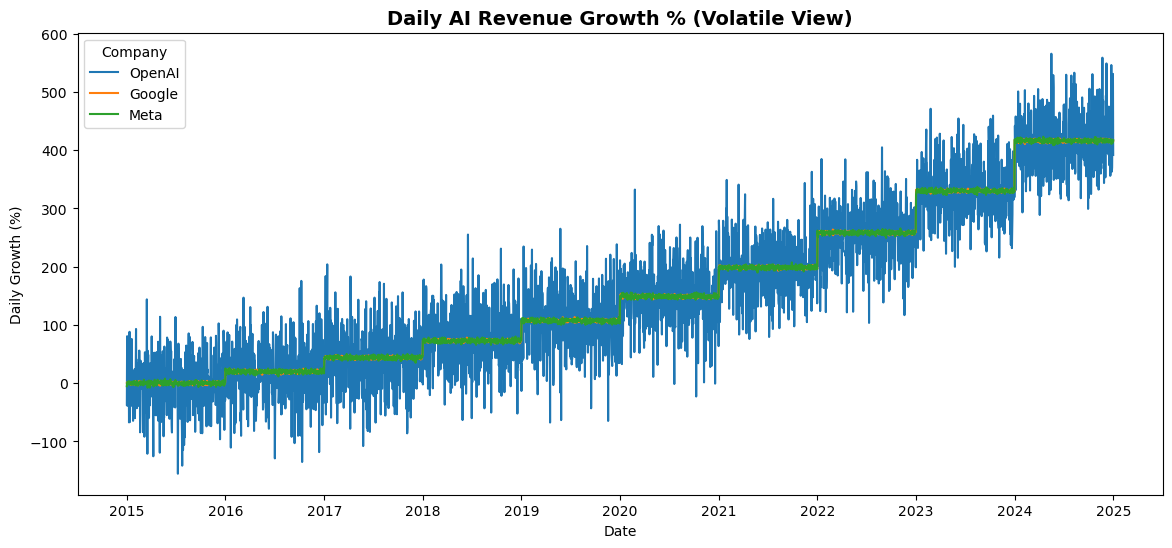

In [18]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    x="Date",
    y="AI_Revenue_Growth_%",
    data=df,
    hue="Company",

)

plt.title('Daily AI Revenue Growth % (Volatile View)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Growth (%)')
plt.show()

**Remark:** The volatility underscores that daily changes are noisy, so annual or smoothed metrics are more useful for strategic insights.

In [23]:
df.sort_values(by = ["AI_Revenue_Growth_%"])

,Data_ID,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,Year,Event
189,A190,2015-07-09,OpenAI,5.66,-0.55,-155.43,0.70,2015,NaN
205,A206,2015-07-25,OpenAI,5.23,-0.42,-141.61,-0.62,2015,NaN
649,A650,2016-10-11,OpenAI,5.37,-0.35,-135.31,0.12,2016,NaN
548,A549,2016-07-02,OpenAI,5.19,-0.29,-129.11,-0.31,2016,NaN
98,A99,2015-04-09,OpenAI,4.80,-0.25,-125.50,-0.56,2015,NaN
...,...,...,...,...,...,...,...,...,...
3508,A3509,2024-08-09,OpenAI,9.92,6.33,532.86,0.77,2024,NaN
3645,A3646,2024-12-24,OpenAI,8.79,6.46,546.07,0.45,2024,NaN
3627,A3628,2024-12-06,OpenAI,8.51,6.49,548.83,-0.15,2024,NaN
3612,A3613,2024-11-21,OpenAI,10.16,6.59,558.70,0.63,2024,NaN


### 3.3. How does Annual AI revenue relate to Average Stock Impact?

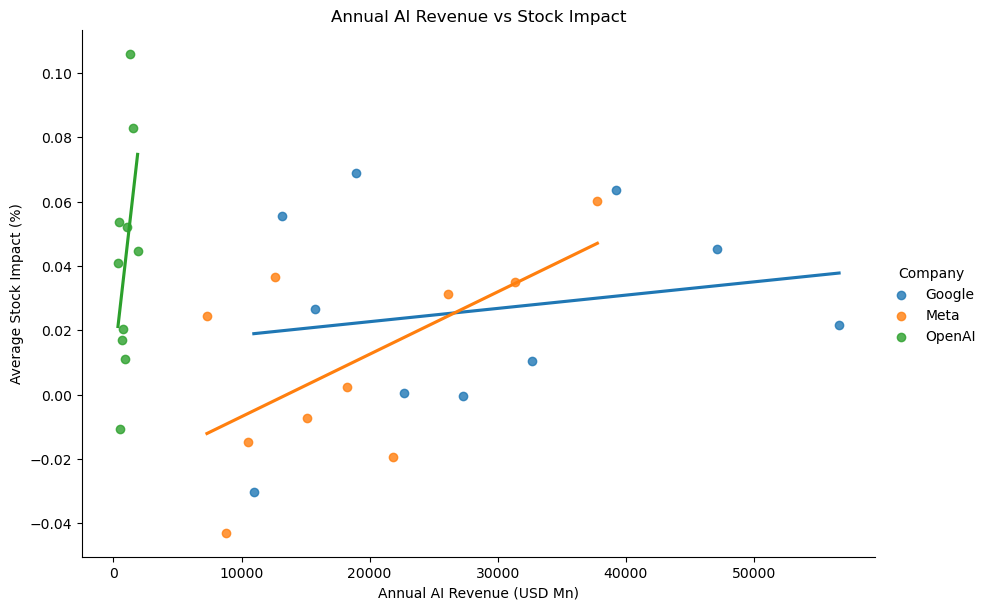

In [24]:
# Sum AI revenue per year per company
annual_revenue = df.groupby(['Year','Company'])['AI_Revenue_USD_Mn'].sum().reset_index()
# Average stock impact per year per company
annual_stock = df.groupby(['Year','Company'])['Stock_Impact_%'].mean().reset_index()
# Combine revenue and stock impact
revenue_vs_stock = pd.merge(annual_revenue, annual_stock, on=['Year','Company'])

import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=revenue_vs_stock,
    x='AI_Revenue_USD_Mn',
    y='Stock_Impact_%',
    hue='Company',
    height=6,
    aspect=1.5,
    markers='o',
    ci=None
)

plt.title("Annual AI Revenue vs Stock Impact")
plt.xlabel("Annual AI Revenue (USD Mn)")
plt.ylabel("Average Stock Impact (%)")
plt.show()

**Remark:** Annual AI revenue and stock Impact do not show a strong direct correlation; market reactions are influenced by multiple factors.


### 3.4. How does AI revenue growth relate to stock price volatility?

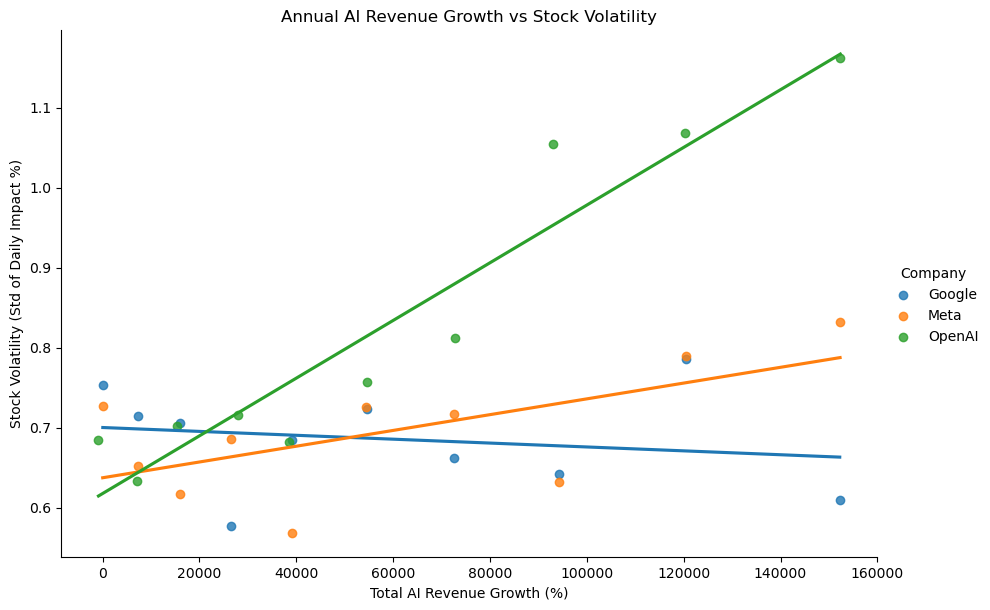

In [38]:
stock_volatility = Cleaned_DFM.groupby(['Year', 'Company'])['Stock_Impact_%'].std().reset_index()
stock_volatility.rename(columns={'Stock_Impact_%':'Stock_Volatility'}, inplace=True)
ai_growth = Cleaned_DFM.groupby(['Year','Company'])['AI_Revenue_Growth_%'].sum().reset_index()  # total growth for the year
volatility_vs_growth = pd.merge(ai_growth, stock_volatility, on=['Year','Company'])

sns.lmplot(
    data=volatility_vs_growth,
    x='AI_Revenue_Growth_%',
    y='Stock_Volatility',
    hue='Company',
    height=6,
    aspect=1.5,
    markers='o',
    ci=None
)

plt.title("Annual AI Revenue Growth vs Stock Volatility")
plt.xlabel("Total AI Revenue Growth (%)")
plt.ylabel("Stock Volatility (Std of Daily Impact %)")
plt.show()


**Remark:** Remark: AI revenue growth and stock volatility do not show a strong direct correlation; market reactions are influenced by multiple factors.

In [338]:
# volatility_vs_growth is already merged and ready
# optional: round values for readability
table_ready = volatility_vs_growth.copy()
table_ready['AI_Revenue_Growth_%'] = table_ready['AI_Revenue_Growth_%'].round(2)
table_ready['Stock_Volatility'] = table_ready['Stock_Volatility'].round(2)

# display top rows
print(table_ready)


    Year Company  AI_Revenue_Growth_%  Stock_Volatility
0   2015  Google                42.28              0.75
1   2015    Meta                20.76              0.73
2   2015  OpenAI              -849.79              0.68
3   2016  Google              7253.95              0.71
4   2016    Meta              7240.95              0.65
5   2016  OpenAI              7076.55              0.63
6   2017  Google             16021.18              0.71
7   2017    Meta             16006.81              0.62
8   2017  OpenAI             15399.80              0.70
9   2018  Google             26580.14              0.58
10  2018    Meta             26480.88              0.69
11  2018  OpenAI             27905.79              0.72
12  2019  Google             39171.96              0.68
13  2019    Meta             39138.55              0.57
14  2019  OpenAI             38589.10              0.68
15  2020  Google             54496.41              0.72
16  2020    Meta             54471.06           

### 3.5. How does AI revenue growth relate to stock price volatility?

In [360]:
event_analysis_df = df.copy()
event_analysis_df['Event'] = event_analysis_df['Event'].notnull() #not null return to True
event_stock_impact = event_analysis_df.groupby('Event')['Stock_Impact_%'].agg(['mean', 'std', 'count'])
print(event_stock_impact)

       mean  std  count
Event                  
False  0.00 0.58  10726
True   1.22 3.08    233


**Remark:** On no-event days, stock movements are small and stable. When events occur, stock impact rises on average (mean 1.22%) with greater variability (std 3.08%), though fewer events occur (count 233).

In [253]:
event_type_impact = df.groupby('Event')['Stock_Impact_%'].agg(['mean', 'std', 'count']).round(2)
event_type_impact = event_type_impact.sort_values('mean', ascending=False) # Sort by most positive impact

print("Average Stock Impact by Event Type:")
print(event_type_impact)

Average Stock Impact by Event Type:
                                 mean  std  count
Event                                            
GPT-5 release (predicted)       18.50  NaN      1
GPT-4 release                   15.20  NaN      1
ChatGPT (GPT-3.5) launch        12.00  NaN      1
DALL·E 2 release                 9.80  NaN      1
GPT-3 release                    8.50  NaN      1
LLaMA 3 release (predicted)      7.40  NaN      1
Codex release                    7.20  NaN      1
LLaMA 2 release                  6.80  NaN      1
AlphaGo beats Lee Sedol          6.20  NaN      1
LLaMA 1 release                  6.10  NaN      1
Gemini AI release                5.80  NaN      1
Bard chatbot launch              5.00  NaN      1
TensorFlow open-source release   4.50  NaN      1
GPT-2 release                    4.20  NaN      1
MUM Search Model launch          4.10  NaN      1
BERT for Search launch           3.20  NaN      1
GPT-1 release                    3.00  NaN      1
AI ethics poli

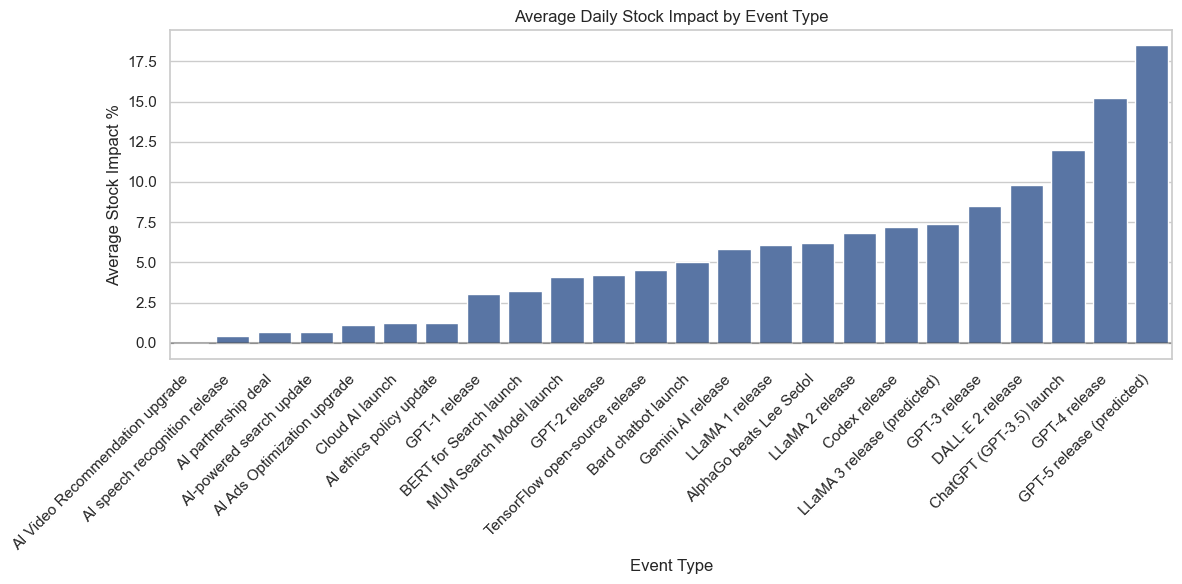

In [295]:
plt.figure(figsize=(12, 6))
filtered_events = event_type_impact.sort_values('mean')
sns.barplot(x=filtered_events.index, y=filtered_events['mean'])
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Average Daily Stock Impact by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Average Stock Impact %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [294]:
# Checking for Particular Event

df [ df.Event == "GPT-4 release"]

,Data_ID,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,Year,Event,AI_Revenue_Growth_Pct,Weighted_Growth,Growth_Smoothed,AI_Efficiency,AI_Growth_Magnitude,Stock_Impact_Magnitude
2994,A2995,2023-03-14,OpenAI,7.78,4.05,304.57,15.20,2023,GPT-4 release,30457.00,1233.51,333.89,0.52,304.57,15.20


In [261]:
gpt4 = df.loc[2984 : 3004]
gpt4

,Data_ID,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,Year,Event,AI_Revenue_Growth_Pct,Weighted_Growth,Growth_Smoothed,AI_Efficiency,AI_Growth_Magnitude,Stock_Impact_Magnitude
2984,A2985,2023-03-04,OpenAI,10.59,4.26,326.43,-0.28,2023,NaN,32643.00,1390.59,324.52,0.40,326.43,0.28
2985,A2986,2023-03-05,OpenAI,8.24,3.58,257.92,-0.48,2023,NaN,25792.00,923.35,329.74,0.43,257.92,0.48
2986,A2987,2023-03-06,OpenAI,9.32,4.21,320.60,0.89,2023,NaN,32060.00,1349.73,329.86,0.45,320.60,0.89
2987,A2988,2023-03-07,OpenAI,8.52,4.13,313.16,-0.08,2023,NaN,31316.00,1293.35,329.62,0.48,313.16,0.08
2988,A2989,2023-03-08,OpenAI,8.90,3.63,263.03,-0.56,2023,NaN,26303.00,954.80,329.35,0.41,263.03,0.56
2989,A2990,2023-03-09,OpenAI,8.44,4.64,363.84,0.91,2023,NaN,36384.00,1688.22,329.29,0.55,363.84,0.91
2990,A2991,2023-03-10,OpenAI,9.55,4.83,383.49,-0.02,2023,NaN,38349.00,1852.26,329.94,0.51,383.49,0.02
2991,A2992,2023-03-11,OpenAI,8.34,3.95,294.67,0.19,2023,NaN,29467.00,1163.95,329.65,0.47,294.67,0.19
2992,A2993,2023-03-12,OpenAI,8.71,3.57,256.88,-0.87,2023,NaN,25688.00,917.06,327.55,0.41,256.88,0.87
2993,A2994,2023-03-13,OpenAI,10.61,5.19,419.06,0.53,2023,NaN,41906.00,2174.92,329.60,0.49,419.06,0.53


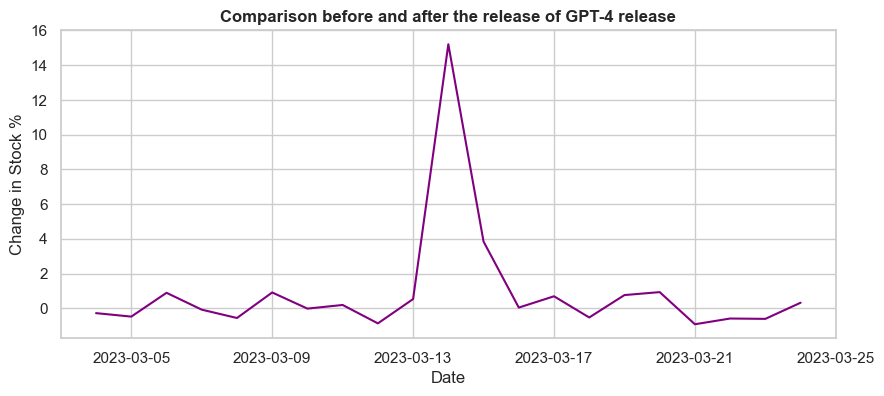

In [262]:
#Showing the impact with a line chart

plt.figure(figsize = (10,4))

plt.plot(gpt4["Date"], gpt4["Stock_Impact_%"], color = "purple")
plt.title('Comparison before and after the release of GPT-4 release', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Change in Stock %')

plt.show()

### Annual Peak Stock Impact per Company

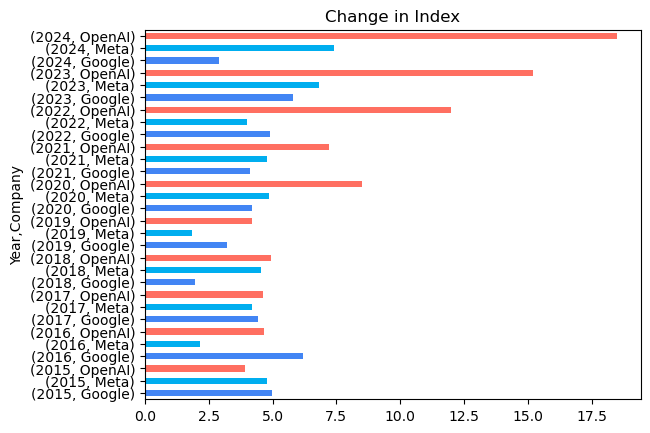

In [28]:
stock = df.groupby(["Year", "Company"])["Stock_Impact_%"].max()
stock

stock.plot(kind="barh", color=["#4285F4", "#00AEEF", "#FF6F61"])
plt.title("Change in Index")
plt.show()

## 4. Key Insights & Implications

### Key Insights

| # | Insight | Detail |
|---|---------|--------|
| 1 | **AI Revenue Growth Is Explosive but Not Always Linked to Stock Volatility** | Companies show rapid AI revenue growth year-over-year, but higher revenue does not consistently translate to higher stock volatility. Market reactions are driven by multiple external factors beyond revenue alone. |
| 2 | **Event Types Drive Stock Performance** | AI-related announcements and product launches create measurably higher stock impact compared to non-event days. Event days show an average impact of ~1.22% vs ~0.00% on non-event days. |
| 3 | **Extreme Stock Movements Are Concentrated Around Key Events** | Outlier trading days represent a small fraction of total days but carry disproportionate impact. These extreme movements cluster around major AI milestones like GPT-4 release. |

### Implications for Decision-Making

| Area | Implication |
|------|-------------|
| **Investment & Risk Management** | OpenAI shows higher volatility → higher risk/reward profile. Portfolio allocation should account for company-specific event exposure. |
| **Strategic Event Planning** | Product releases and announcements can meaningfully move stock prices. Timing and communication strategy matter. |
| **Long-Term Growth vs Market Reaction** | Sustainable growth and market perception matter more than raw revenue numbers. Extreme moves around events are useful signals for forecasting. |